## Working with Tilecode in Vgrid DGGS

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeoshub/vgrid/blob/main/docs/notebooks/15_tilecode.ipynb)
[![image](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/opengeoshub/vgrid/HEAD?filepath=docs/notebooks/15_tilecode.ipynb)
[![image](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/opengeoshub/vgrid/blob/main/docs/notebooks/15_tilecode.ipynb)
[![image](https://jupyterlite.rtfd.io/en/latest/_static/badge.svg)](https://jupyterlite.gishub.vn/lab/index.html?path=notebooks/vgrid/15_tilecode.ipynb)

Full Vgrid DGGS documentation is available at [vgrid document](https://vgrid.gishub.vn).

To work with Vgrid DGGS directly in GeoPandas and Pandas, please use [vgridpandas](https://pypi.org/project/vgridpandas/). Full Vgridpandas DGGS documentation is available at [vgridpandas document](https://vgridpandas.gishub.vn).

To work with Vgrid DGGS in QGIS, install the [Vgrid Plugin](https://plugins.qgis.org/plugins/vgridtools/).

To visualize DGGS in Maplibre GL JS, try the [vgrid-maplibre](https://www.npmjs.com/package/vgrid-maplibre) library.

For an interactive demo, visit the [Vgrid Homepage](https://vgrid.vn).

### Install vgrid
Uncomment the following line to install [vgrid](https://pypi.org/project/vgrid/).

In [1]:
# %pip install vgrid --upgrade

### latlon2tilecode

In [1]:
from vgrid.conversion.latlon2dggs import latlon2tilecode

lat = 10.775276
lon = 106.706797
res = 14
tilecode_id = latlon2tilecode(lat, lon, res)
tilecode_id

'z14x13048y7698'

### Tilecode to Polygon

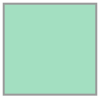

In [2]:
from vgrid.conversion.dggs2geo.tilecode2geo import tilecode2geo

tilecode_geo = tilecode2geo(tilecode_id)
tilecode_geo

### Tilecode to GeoJSON        

In [ ]:
from vgrid.conversion.dggs2geo.tilecode2geo import tilecode2geojson

tilecode_geojson = tilecode2geojson(tilecode_id)
# tilecode_geojson

### Vector to Tilecode

#### Multi(Point) to Tilecode

Processing features: 100%|██████████| 12/12 [00:00<00:00, 4791.21it/s]


<Axes: >

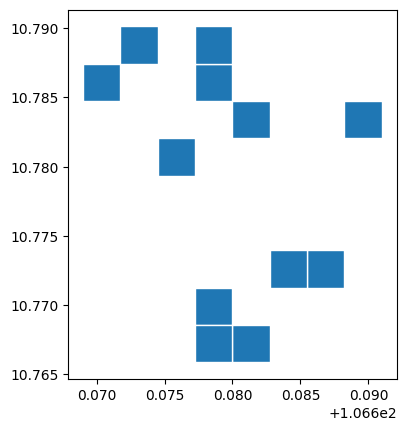

In [1]:
from vgrid.conversion.vector2dggs.vector2tilecode import vector2tilecode

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/point.geojson"
)
point_to_tilecode = vector2tilecode(
    file_path,
    # resolution=17,
    topology=True,
    output_format="gpd",
)
point_to_tilecode.plot(edgecolor="white")

#### Multi(Polygon) to Tilecode

Processing features: 100%|██████████| 1/1 [00:00<00:00, 20.05it/s]


<Axes: >

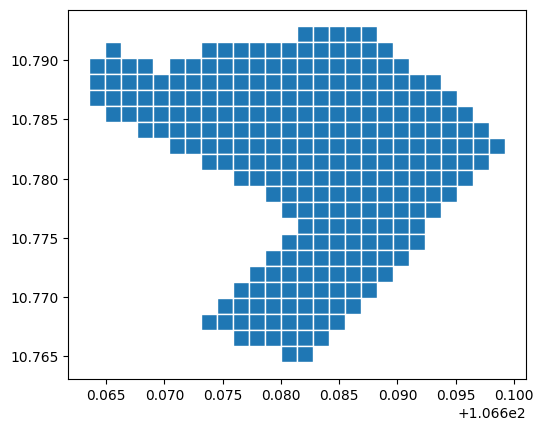

In [ ]:
from vgrid.conversion.vector2dggs.vector2tilecode import vector2tilecode

file_path = "https://raw.githubusercontent.com/opengeoshub/vopendata/main/shape/polygon2.geojson"
vector_to_tilecode = vector2tilecode(
    file_path,
    compact=False,
    resolution=18,
    predicate="intersects",
    output_format="gpd",
)
vector_to_tilecode.plot(edgecolor="white")

### Tilecode Compact

<Axes: >

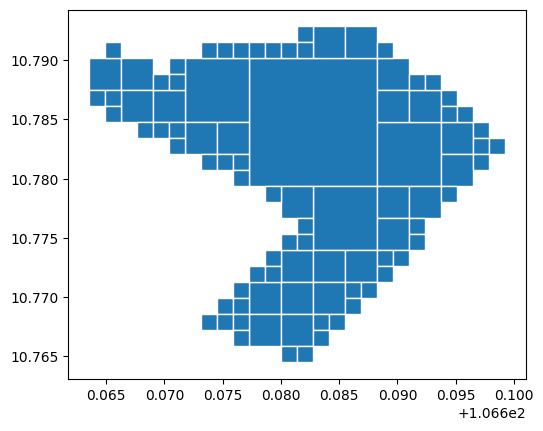

In [2]:
from vgrid.conversion.dggscompact.tilecodecompact import tilecodecompact

tilecode_compacted = tilecodecompact(
    vector_to_tilecode, tilecode_id="tilecode", output_format="gpd"
)
tilecode_compacted.plot(edgecolor="white")

### Tilecode Expand

<Axes: >

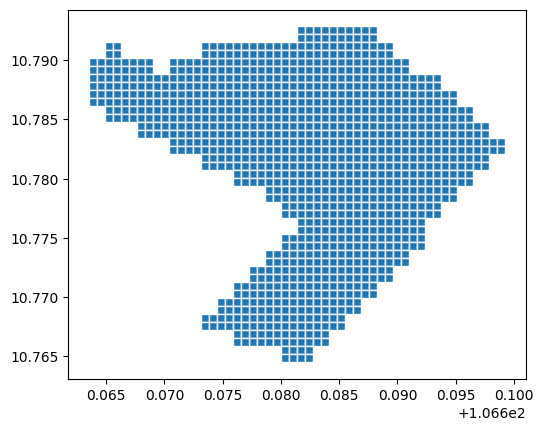

In [3]:
from vgrid.conversion.dggscompact.tilecodecompact import tilecodeexpand

tilecode_expanded = tilecodeexpand(
    vector_to_tilecode, resolution=19, output_format="gpd"
)
tilecode_expanded.plot(edgecolor="white")

### Tilecode Binning

Generating Tilecode DGGS: 1015 cells [00:00, 1298.40 cells/s]


<Axes: >

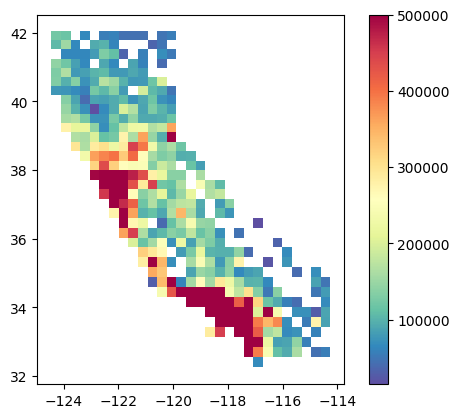

In [1]:
from vgrid.binning.tilecodebin import tilecodebin

file_path = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/csv/housing.csv"
)
stats = "max"
numeric_col = "median_house_value"

tilecode_bin = tilecodebin(
    file_path,
    resolution=10,
    stats=stats,
    numeric_col=numeric_col,
    # category_col="category",
    output_format="gpd",
)
tilecode_bin.plot(
    column=f"{numeric_col}_{stats}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Tilecode Resampling

Generating A5 cells: 100%|██████████| 2011/2011 [00:00<00:00, 2515.04 cells/s]


<Axes: >

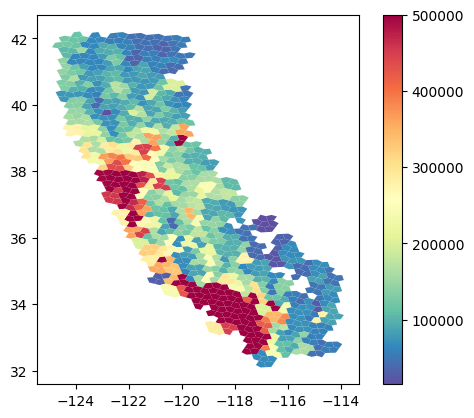

In [2]:
from vgrid.conversion.dggsresample import dggsresample

tilecode_resample = dggsresample(
    source_dggs=tilecode_bin,
    dggs_from="tilecode",
    dggs_to="a5",
    method="nearest",  # area_weighted, nearest
    dggs_col="tilecode",
    resample_col=f"{numeric_col}_{stats}",  # column on h3_bin with numbers
    fix_antimeridian=None,
    split_antimeridian=False,
)
tilecode_resample.plot(
    column=f"{numeric_col}_{stats}",  # numeric column to base the colors on
    cmap="Spectral_r",  # color scheme (matplotlib colormap)
    legend=True,
    linewidth=0.2,  # boundary width (optional)
)

### Raster to Tilecode

#### Download and open raster

rgb.tif already exists. Skip downloading. Set overwrite=True to overwrite.
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': None, 'width': 240, 'height': 147, 'count': 3, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(2.6640125000199077e-06, 0.0, 106.708118755,
       0.0, -2.6640136054383103e-06, 10.812568272)}


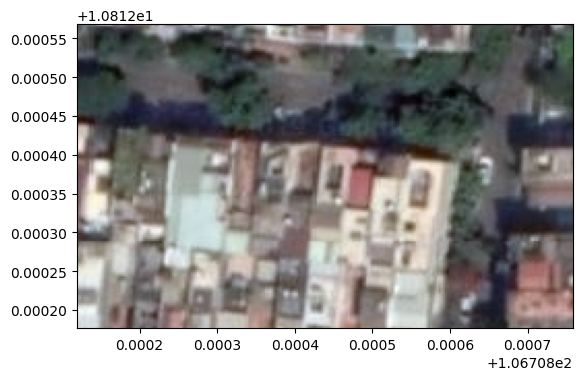

<Axes: >

In [3]:
from vgrid.utils.io import download_file
import rasterio
from rasterio.plot import show

raster_url = (
    "https://raw.githubusercontent.com/opengeoshub/vopendata/main/raster/rgb.tif"
)
raster_file = download_file(raster_url)
src = rasterio.open(raster_file, "r")
print(src.meta)
show(src)

#### Convert raster to Tilecode

In [10]:
# %pip install folium

In [5]:
from vgrid.conversion.raster2dggs.raster2tilecode import raster2tilecode

raster_to_tilecode = raster2tilecode(
    raster_file,
    method="binning",  # nearest, binning
    stats="mean",
    output_format="gpd",
)

# Visualize the output
import folium

m = folium.Map(tiles="CartoDB positron", max_zoom=28)

tilecode_layer = folium.GeoJson(
    raster_to_tilecode,
    style_function=lambda x: {
        "fillColor": f"rgb({x['properties']['band_1']}, {x['properties']['band_2']}, {x['properties']['band_3']})",
        "fillOpacity": 1,
        "color": "black",
        "weight": 1,
    },
    popup=folium.GeoJsonPopup(
        fields=["tilecode", "band_1", "band_2", "band_3"],
        aliases=["Tilecode ID", "Band 1", "Band 2", "Band 3"],
        style="""
            background-color: white;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
        """,
    ),
).add_to(m)

m.fit_bounds(tilecode_layer.get_bounds())

# Display the map
m

Cell size: 0.08638527081938627 m2
Nearest Tilecode resolution determined: 26
Method: binning
Stats: mean


Binning raster blocks to Tilecode:   0%|          | 0/14 [00:00<?, ? block/s]

Converting raster to Tilecode: 100%|██████████| 8880/8880 [00:00<00:00, 9610.91 cells/s] 


### Tilecode Generator

Generating Tilecode DGGS: 100%|██████████| 39/39 [00:00<00:00, 7690.90 cells/s]


<Axes: >

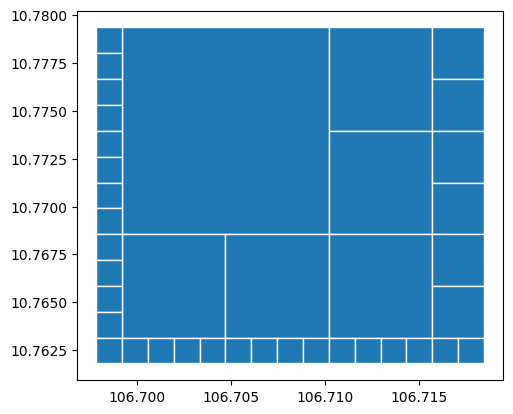

In [2]:
from vgrid.generator.tilecodegrid import tilecodegrid

# tilecode_grid = tilecodegrid(resolution=2,output_format="gpd")
tilecode_grid = tilecodegrid(
    resolution=18,
    bbox=[106.699007, 10.762811, 106.717674, 10.778649],
    compact=True,
    output_format="gpd",
)
tilecode_grid.plot(edgecolor="white")

### Tilecode Inspect

In [1]:
from vgrid.stats.tilecodestats import tilecodeinspect

resolution = 7
tilecode_inspect = tilecodeinspect(resolution)
tilecode_inspect.head()

Generating Tilecode DGGS: 100%|██████████| 16384/16384 [00:00<00:00, 20061.79 cells/s]


,tilecode,resolution,center_lat,center_lon,cell_width,cell_height,cell_area,cell_perimeter,geometry,crossed,norm_area,ipq,zsc,cvh
0,z7x0y0,7,84.926801,-178.59375,28454.129379,27771.076917,7.711209e+08,111092.677554,"POLYGON ((-180 84.80247, -177.1875 84.80247, -...",False,0.024769,0.785166,0.886095,1.0
1,z7x0y1,7,84.671917,-178.59375,29879.298302,29162.168544,8.503136e+08,116657.764770,"POLYGON ((-180 84.54136, -177.1875 84.54136, -...",False,0.027313,0.785166,0.886095,1.0
2,z7x0y2,7,84.404267,-178.59375,31375.155502,30622.279581,9.375993e+08,122499.012966,"POLYGON ((-180 84.26717, -177.1875 84.26717, -...",False,0.030117,0.785167,0.886096,1.0
3,z7x0y3,7,84.123216,-178.59375,32945.097361,32154.729646,1.033796e+09,128629.712154,"POLYGON ((-180 83.97926, -177.1875 83.97926, -...",False,0.033207,0.785167,0.886096,1.0
4,z7x0y4,7,83.828101,-178.59375,34592.666003,33762.981365,1.139804e+09,135063.726094,"POLYGON ((-180 83.67694, -177.1875 83.67694, -...",False,0.036612,0.785168,0.886096,1.0


### Tilecode Normalized Area Histogram

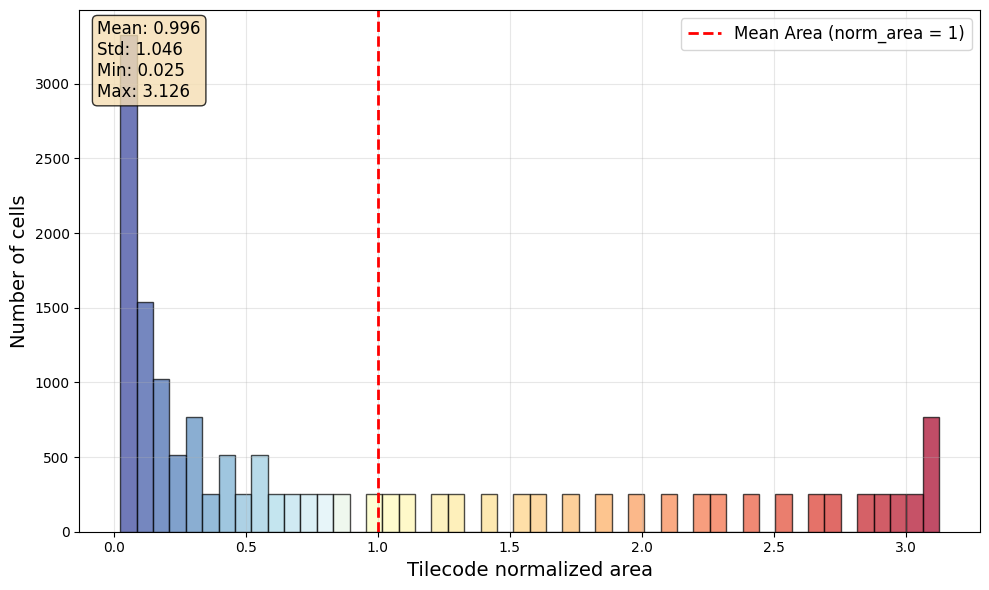

In [2]:
from vgrid.stats.tilecodestats import tilecode_norm_area_hist

tilecode_norm_area_hist(tilecode_inspect)

### Distribution of Tilecode Area Distortions

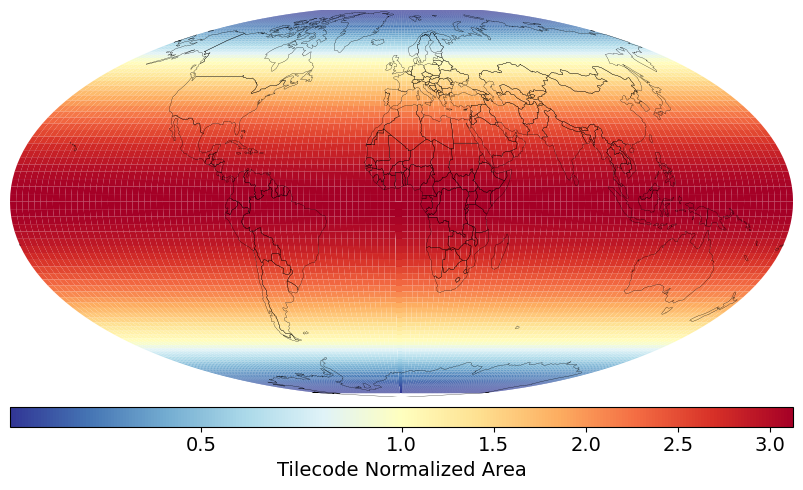

In [3]:
from vgrid.stats.tilecodestats import tilecode_norm_area

tilecode_norm_area(tilecode_inspect)

### Tilecode IPQ Compactness Histogram

Isoperimetric Inequality (IPQ) Compactness (suggested by [Osserman, 1978](https://sites.math.washington.edu/~toro/Courses/20-21/MSF/osserman.pdf)):

$$C_{IPQ} = \frac{4 \pi A}{p^2}$$
The range of the IPQ compactness metric is (0,1]. 

A circle represents the maximum compactness with a value of 1. 

As shapes become more irregular or elongated, their compactness decreases toward 0.

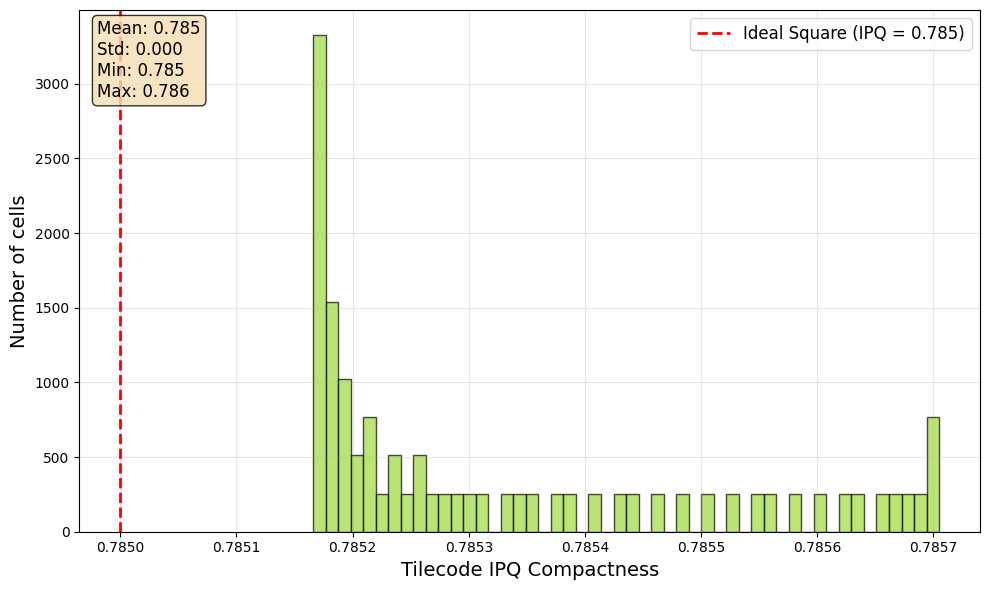

In [4]:
from vgrid.stats.tilecodestats import tilecode_compactness_ipq_hist

tilecode_compactness_ipq_hist(tilecode_inspect)

### Distribution of Tilecode IPQ Compactness

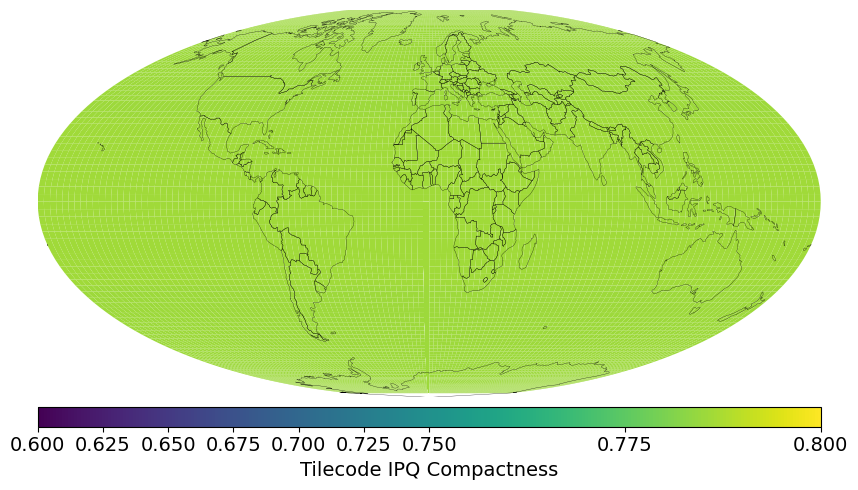

In [5]:
from vgrid.stats.tilecodestats import tilecode_compactness_ipq

tilecode_compactness_ipq(tilecode_inspect)

### Tilecode Convex hull Compactness Histogram:

$$C_{CVH} = \frac{A}{A_{CVH}}$$


The range of the convex hull compactness metric is (0,1]. 

As shapes become more concave, their convex hull compactness decreases toward 0.

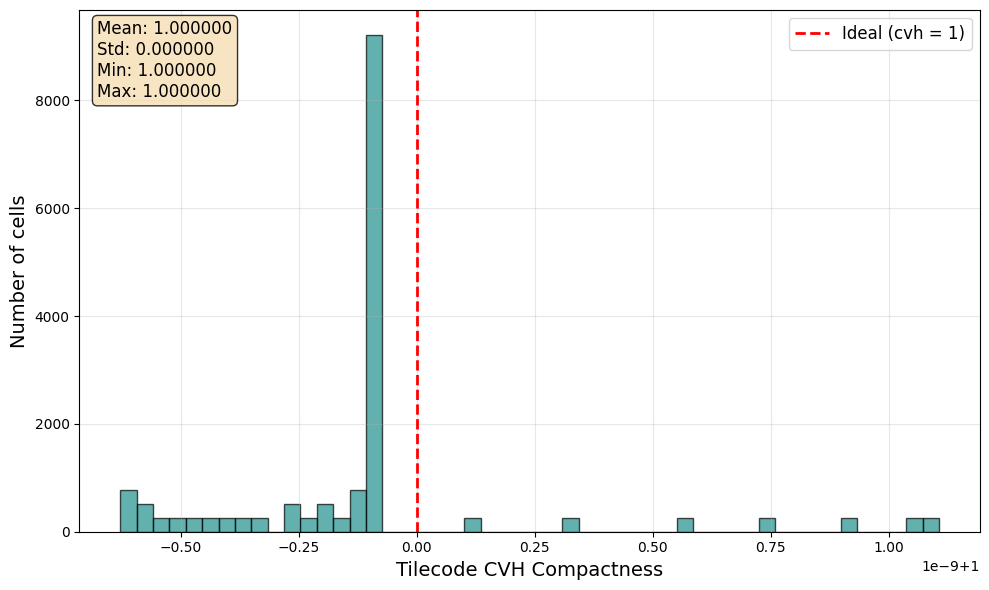

In [6]:
from vgrid.stats.tilecodestats import tilecode_compactness_cvh_hist

tilecode_compactness_cvh_hist(tilecode_inspect)

### Distribution of Tilecode Convex hull Compactness

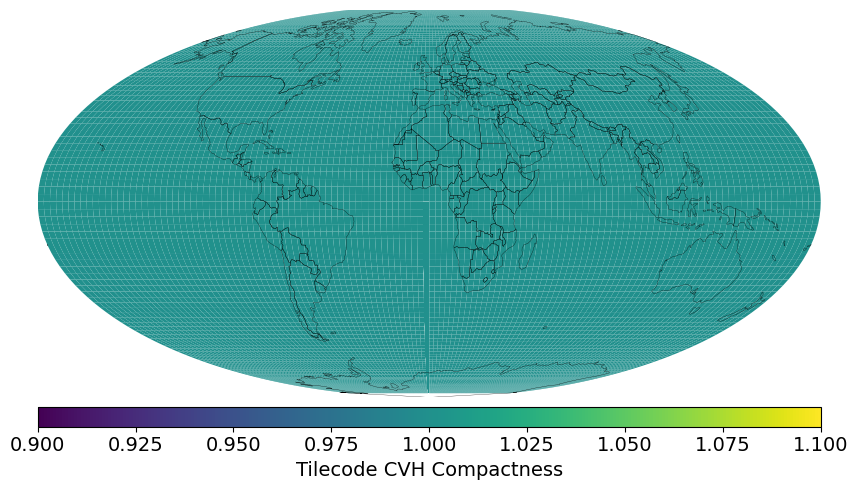

In [7]:
from vgrid.stats.tilecodestats import tilecode_compactness_cvh

tilecode_compactness_cvh(tilecode_inspect)

### Tilecode Statistics

Characteristic Length Scale (CLS - suggested by Ralph Kahn): the diameter of a spherical cap of the same cell's area

In [2]:
from vgrid.stats import tilecodestats

tilecodestats("km")

,resolution,number_of_cells,avg_edge_len_km,avg_cell_area_km2,cls_km
0,0,1,22584.632424,5.100656e+08,40030.218711
1,1,4,11292.316212,1.275164e+08,13343.406237
2,2,16,5646.158106,3.187910e+07,6439.310880
3,3,64,2823.079053,7.969775e+06,3193.858049
4,4,256,1411.539526,1.992444e+06,1593.790570
5,5,1024,705.769763,4.981110e+05,796.505573
6,6,4096,352.884882,1.245277e+05,398.204153
7,7,16384,176.442441,3.113193e+04,199.096000
8,8,65536,88.221220,7.782984e+03,99.547240
9,9,262144,44.110610,1.945746e+03,49.773525
